# Improved Model Fitting

The main goal of this notebook is to fit the proposed model to the available data and perform a first visual evaluation of its performance, prior to the proper model validation, evaluation and interpretation.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tumorgrowth-processed.csv"
EXPORT_PATH = PROJECT_ROOT / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.improved_model import simulate_tumor
from src.models.fit_improved_model import fit_model, truncate_dataset

In [3]:
data = pd.read_csv(DATA_PATH)

data.head()

,Grp,Group,ID,Day,Size,Baseline,RTV
0,1.CTR,1,101,0,41.8,41.8,1.000000
1,1.CTR,1,101,3,85.0,41.8,2.033493
2,1.CTR,1,101,4,114.0,41.8,2.727273
3,1.CTR,1,101,5,162.3,41.8,3.882775
4,1.CTR,1,101,6,178.3,41.8,4.265550


## Model Fitting

The first step is to fit the model to the available data.

In [4]:
%%time
seed = 23 ; maxiter = 10 ; popsize = 5

group_results, mouse_results = fit_model(data, seed, maxiter, popsize, 15)

mouse_results.head()

CPU times: total: 3min 47s
Wall time: 4min 16s


,ID,Group,r_id,eta_i
0,101,1,0.294472,0.004058
1,102,1,0.209422,-0.080992
2,103,1,0.319185,0.028771
3,104,1,0.244607,-0.045806
4,105,1,0.283735,-0.006678


In [5]:
group_results.head()

,Group,bar_r_s,K,al,sigma_r,Global_Loss
0,1,0.290414,7467.980254,0.000000,0.3,0.079517
1,2,0.290414,7467.980254,0.102278,0.3,0.079517
2,3,0.290414,7467.980254,0.034319,0.3,0.079517
3,4,0.290414,7467.980254,0.084812,0.3,0.079517


## Visual Inspection

Once the model has been fitted to the available data it is helpful to plot several instances of its prediction against observed values in order to perform a first visual inspection of its performance.

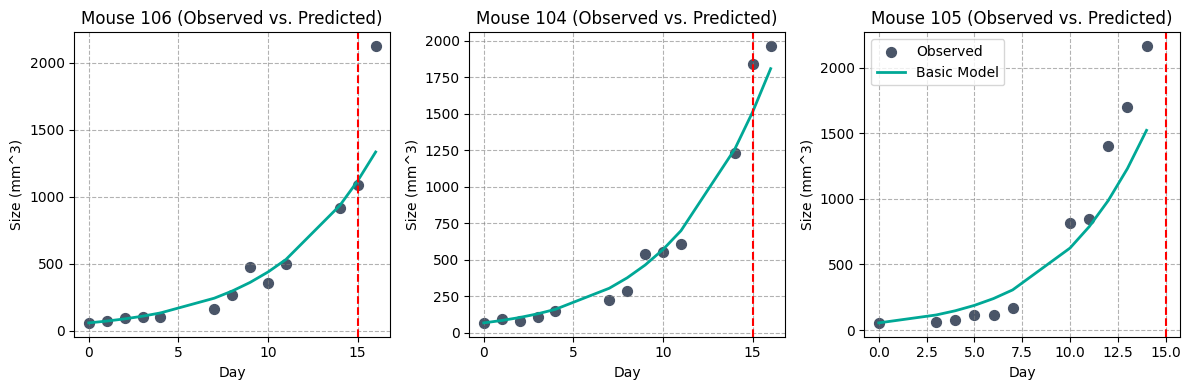

In [9]:
import random

# Group 1 (Control group)
mice_grp1 = data[data["Group"] == 1]
id1, id2, id3 = random.sample(list(mice_grp1["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_1 = mouse_results.loc[mouse_results["ID"] == id1, "r_id"].iloc[0]
r_2 = mouse_results.loc[mouse_results["ID"] == id2, "r_id"].iloc[0]
r_3 = mouse_results.loc[mouse_results["ID"] == id3, "r_id"].iloc[0]

K = group_results["K"].iloc[0]
al = group_results.loc[group_results["Group"]==1, "al"].iloc[0]

D = False

sim_df1 = simulate_tumor(
    T0=T0_1,
    r=r_1,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor(
    T0=T0_2,
    r=r_2,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor(
    T0=T0_3,
    r=r_3,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.axvline(15, color='red', linestyle='--')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.axvline(15, color='red', linestyle='--')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.axvline(15, color='red', linestyle='--')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig13.png", dpi=300, bbox_inches="tight")
plt.show()

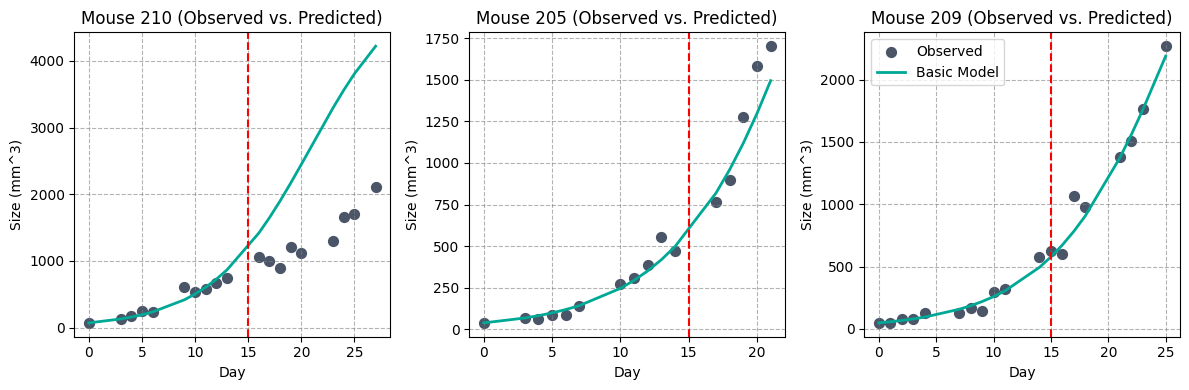

In [11]:
# Group 2 (Only drug)
mice_grp2 = data[data["Group"] == 2]
id1, id2, id3 = random.sample(list(mice_grp2["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_1 = mouse_results.loc[mouse_results["ID"] == id1, "r_id"].iloc[0]
r_2 = mouse_results.loc[mouse_results["ID"] == id2, "r_id"].iloc[0]
r_3 = mouse_results.loc[mouse_results["ID"] == id3, "r_id"].iloc[0]

K = group_results["K"].iloc[0]
al = group_results.loc[group_results["Group"]==2, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor(
    T0=T0_1,
    r=r_1,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor(
    T0=T0_2,
    r=r_2,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor(
    T0=T0_3,
    r=r_3,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.axvline(15, color='red', linestyle='--')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.axvline(15, color='red', linestyle='--')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.axvline(15, color='red', linestyle='--')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig14.png", dpi=300, bbox_inches="tight")
plt.show()

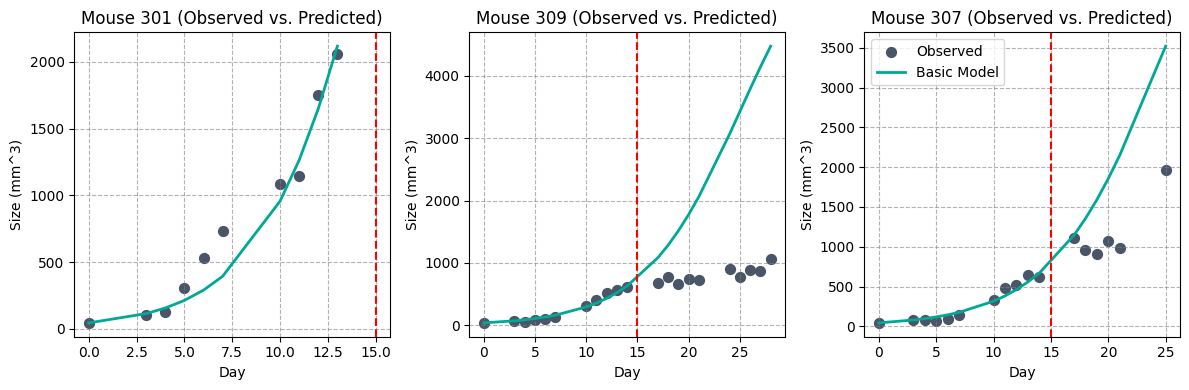

In [13]:
# Group 3 (Only radiation)
mice_grp3 = data[data["Group"] == 3]
id1, id2, id3 = random.sample(list(mice_grp3["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_1 = mouse_results.loc[mouse_results["ID"] == id1, "r_id"].iloc[0]
r_2 = mouse_results.loc[mouse_results["ID"] == id2, "r_id"].iloc[0]
r_3 = mouse_results.loc[mouse_results["ID"] == id3, "r_id"].iloc[0]

K = group_results["K"].iloc[0]
al = group_results.loc[group_results["Group"]==3, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor(
    T0=T0_1,
    r=r_1,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor(
    T0=T0_2,
    r=r_2,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor(
    T0=T0_3,
    r=r_3,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.axvline(15, color='red', linestyle='--')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.axvline(15, color='red', linestyle='--')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.axvline(15, color='red', linestyle='--')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig15.png", dpi=300, bbox_inches="tight")
plt.show()

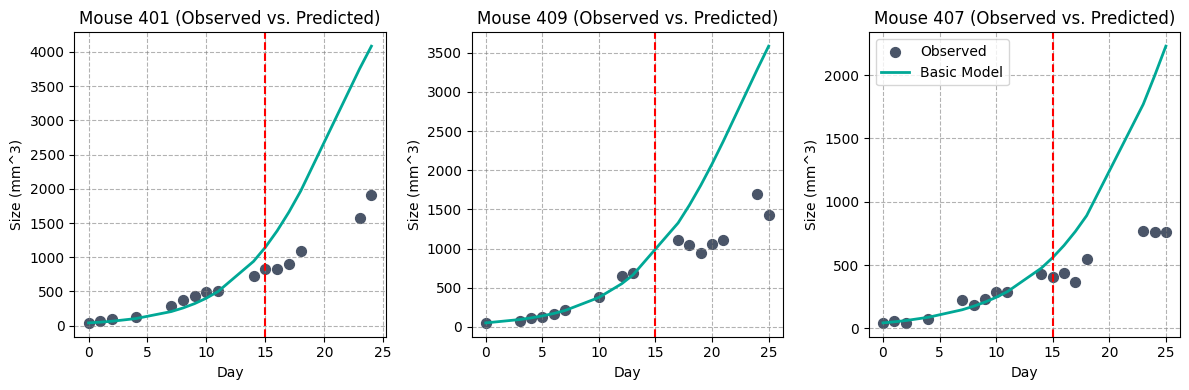

In [14]:
# Group 4 (Drug + Radiation)
mice_grp4 = data[data["Group"] == 4]
id1, id2, id3 = random.sample(list(mice_grp4["ID"].unique()), 3)

data_id1 = data[data["ID"] == id1]
data_id2 = data[data["ID"] == id2]
data_id3 = data[data["ID"] == id3]

T_obs1 = data_id1["Size"].to_numpy()
T_obs2 = data_id2["Size"].to_numpy()
T_obs3 = data_id3["Size"].to_numpy()

times_1 = data_id1["Day"].to_numpy()
times_2 = data_id2["Day"].to_numpy()
times_3 = data_id3["Day"].to_numpy()

T0_1 = T_obs1[0]
T0_2 = T_obs2[0]
T0_3 = T_obs3[0]

r_1 = mouse_results.loc[mouse_results["ID"] == id1, "r_id"].iloc[0]
r_2 = mouse_results.loc[mouse_results["ID"] == id2, "r_id"].iloc[0]
r_3 = mouse_results.loc[mouse_results["ID"] == id3, "r_id"].iloc[0]

K = group_results["K"].iloc[0]
al = group_results.loc[group_results["Group"]==4, "al"].iloc[0]

D = True

sim_df1 = simulate_tumor(
    T0=T0_1,
    r=r_1,
    K=K,
    al=al,
    times=times_1,
    D=D
)

sim_df2 = simulate_tumor(
    T0=T0_2,
    r=r_2,
    K=K,
    al=al,
    times=times_2,
    D=D
)

sim_df3 = simulate_tumor(
    T0=T0_3,
    r=r_3,
    K=K,
    al=al,
    times=times_3,
    D=D
)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

ax1.scatter(times_1,
            T_obs1,
            label="Observed",
            s=50,
            color="#4A5568")

ax1.plot(sim_df1["Day"],
        sim_df1["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax1.set_xlabel("Day")
ax1.set_ylabel("Size (mm^3)")
ax1.set_title(f'Mouse {id1} (Observed vs. Predicted)')
ax1.axvline(15, color='red', linestyle='--')
ax1.grid(True, linestyle='--', alpha=0.6, color='gray')


ax2.scatter(times_2,
            T_obs2,
            label="Observed",
            s=50,
            color="#4A5568")

ax2.plot(sim_df2["Day"],
        sim_df2["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax2.set_xlabel("Day")
ax2.set_ylabel("Size (mm^3)")
ax2.set_title(f'Mouse {id2} (Observed vs. Predicted)')
ax2.axvline(15, color='red', linestyle='--')
ax2.grid(True, linestyle='--', alpha=0.6, color='gray')


ax3.scatter(times_3,
            T_obs3,
            label="Observed",
            s=50,
            color="#4A5568")

ax3.plot(sim_df3["Day"],
        sim_df3["Size"],
        label="Basic Model",
        linewidth=2,
        color="#00A896")

ax3.set_xlabel("Day")
ax3.set_ylabel("Size (mm^3)")
ax3.set_title(f'Mouse {id3} (Observed vs. Predicted)')
ax3.axvline(15, color='red', linestyle='--')
ax3.grid(True, linestyle='--', alpha=0.6, color='gray')


plt.legend()
plt.tight_layout()

fig.savefig(EXPORT_PATH / "fig16.png", dpi=300, bbox_inches="tight")
plt.show()

At first sight the model behaves as expected: it does a great job at modelling the behavior of the tumors when $Day \leq 15$ (training window) and it tends to overpredict observations for $Day \geq 16$. This is due to the fact that the real-world dataset past Day 15 is mostly formed by mice with slower-growing tumors (which are only a subpopulation of all mice).

Therefore, prior to any validation or evaluation the model seems to correctly capture early growth kinetics.

Single-compartment logistic models assume constant growth rate ($r$) and carrying capacity ($K$). In real late-stage tumors:

Necrosis & Hypoxia: Large tumor cores run out of oxygen and blood supply, causing cell death and flattening the growth curve below $K$.

Cumulative Drug/Radiation Toxicity: Delayed tissue damage or systemic toxicity in mice can alter growth dynamics in ways simple linear death terms ($\alpha D V$) do not capture.

How to Frame This in Your ReportPresent this finding as a validation result:

Model Capability ($t \le 15$): Demonstrates that the discrete-time logistic framework with individual random effects ($r_{s,i}$) successfully captures uninhibited and early treatment tumor dynamics when data is complete and unbiased.

Structural Boundary ($t > 15$): Demonstrates why training on $t \le 15$ was necessary to prevent euthanasia dropout from corrupting early parameter estimates, and highlights where future model iterations could introduce late-stage biological mechanisms (like necrotic core formation or joint survival modeling).